In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from src.data import get_data, split_data
from src.features import clean_data, prepare_data, clean_data_xgb

import xgboost as xgb

In [2]:
df = get_data()
df.shape

(148670, 34)

In [3]:
df_train, df_val, df_test, df_full_train = split_data(df)

In [5]:
df_train.head()

,id,year,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,business_or_commercial,...,credit_type,credit_score,co-applicant_credit_type,age,submission_of_application,ltv,region,security_type,status,dtir1
0,114476,2019,cf,sex_not_available,nopre,type1,p3,l1,nopc,nob/c,...,exp,663,exp,65-74,to_inst,55.527211,south,direct,0,42.0
1,28663,2019,cf,male,nopre,type1,p3,l1,nopc,nob/c,...,cib,572,exp,45-54,to_inst,53.627968,north,direct,0,20.0
2,34413,2019,cf,sex_not_available,nopre,type1,p1,l1,nopc,nob/c,...,exp,808,exp,35-44,to_inst,59.965831,south,direct,0,38.0
3,65252,2019,cf,sex_not_available,nopre,type2,p3,l1,nopc,b/c,...,equi,607,exp,55-64,to_inst,NaN,south,direct,1,NaN
4,46636,2019,cf,joint,nopre,type1,p1,l1,nopc,nob/c,...,crif,678,exp,35-44,to_inst,93.639053,north,direct,1,41.0


In [ ]:
df_train, medians = clean_data(df_train, fit=True)

In [7]:
df_train.head()

,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,business_or_commercial,loan_amount,term,...,credit_score,co-applicant_credit_type,age,submission_of_application,ltv,region,security_type,status,dtir1,dtir1_was_missing
0,cf,sex_not_available,nopre,type1,p3,l1,nopc,nob/c,326500,360.0,...,663,exp,65-74,to_inst,55.527211,south,direct,0,42.0,0
1,cf,male,nopre,type1,p3,l1,nopc,nob/c,406500,360.0,...,572,exp,45-54,to_inst,53.627968,north,direct,0,20.0,0
2,cf,sex_not_available,nopre,type1,p1,l1,nopc,nob/c,526500,180.0,...,808,exp,35-44,to_inst,59.965831,south,direct,0,38.0,0
3,cf,sex_not_available,nopre,type2,p3,l1,nopc,b/c,66500,360.0,...,607,exp,55-64,to_inst,75.122549,south,direct,1,39.0,1
4,cf,joint,nopre,type1,p1,l1,nopc,nob/c,316500,324.0,...,678,exp,35-44,to_inst,93.639053,north,direct,1,41.0,0


In [8]:
medians

{'income': np.float64(5760.0),
 'dtir1': np.float64(39.0),
 'property_value': np.float64(418000.0),
 'ltv': np.float64(75.12254902)}

In [9]:
df_val, medians = clean_data(df_val, fit=False, medians=medians)

In [10]:
df_val.shape

(28747, 29)

In [11]:
medians

{'income': np.float64(5760.0),
 'dtir1': np.float64(39.0),
 'property_value': np.float64(418000.0),
 'ltv': np.float64(75.12254902)}

In [12]:
df_train.nunique().sort_values(ascending=False)

ltv                          6840
income                        846
credit_score                  401
property_value                345
loan_amount                   192
dtir1                          57
term                           25
age                             7
region                          4
total_units                     4
gender                          4
loan_purpose                    4
loan_type                       3
occupancy_type                  3
interest_only                   2
neg_ammortization               2
business_or_commercial          2
credit_worthiness               2
open_credit                     2
loan_limit                      2
approv_in_adv                   2
lump_sum_payment                2
co-applicant_credit_type        2
construction_type               2
secured_by                      2
submission_of_application       2
security_type                   2
status                          2
dtir1_was_missing               2
dtype: int64

In [13]:
X_train, y_train, encoder, scaler, features = prepare_data(df_train, fit=True)


In [14]:
X_train, y_train

(array([[-0.02831064,  0.42821798,  0.28662939, ...,  1.        ,
          0.        ,  0.        ],
        [ 0.40826269,  0.42821798,  0.787673  , ...,  0.        ,
          0.        ,  0.        ],
        [ 1.0631227 , -2.64521029,  1.14135084, ...,  1.        ,
          0.        ,  0.        ],
        ...,
        [ 0.51740603,  0.42821798,  0.22768309, ...,  0.        ,
          0.        ,  0.        ],
        [ 0.8994077 ,  0.42821798,  1.81923336, ...,  1.        ,
          0.        ,  0.        ],
        [ 0.13540436,  0.42821798, -0.12599475, ...,  1.        ,
          0.        ,  0.        ]], shape=(86399, 43)),
 array([0, 0, 0, ..., 0, 0, 1], shape=(86399,)))

In [15]:
len(features), features

(43,
 ['loan_amount',
  'term',
  'property_value',
  'income',
  'credit_score',
  'ltv',
  'dtir1',
  'loan_limit_ncf',
  'gender_joint',
  'gender_male',
  'gender_sex_not_available',
  'approv_in_adv_pre',
  'loan_type_type2',
  'loan_type_type3',
  'loan_purpose_p2',
  'loan_purpose_p3',
  'loan_purpose_p4',
  'credit_worthiness_l2',
  'open_credit_opc',
  'business_or_commercial_nob/c',
  'neg_ammortization_not_neg',
  'interest_only_not_int',
  'lump_sum_payment_not_lpsm',
  'construction_type_sb',
  'occupancy_type_pr',
  'occupancy_type_sr',
  'secured_by_land',
  'total_units_2u',
  'total_units_3u',
  'total_units_4u',
  'co-applicant_credit_type_exp',
  'age_35-44',
  'age_45-54',
  'age_55-64',
  'age_65-74',
  'age_<25',
  'age_>74',
  'submission_of_application_to_inst',
  'region_north',
  'region_north-east',
  'region_south',
  'security_type_indriect',
  'dtir1_was_missing_1'])

In [16]:
X_val, y_val, _, _,features_val = prepare_data(df_val, encoder=encoder, scaler=scaler)

In [17]:
X_val

array([[-1.06517232,  0.42821798, -0.21441421, ...,  0.        ,
         0.        ,  1.        ],
       [-0.13745398,  0.42821798, -0.42072629, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.18997602,  0.42821798, -0.21441421, ...,  1.        ,
         0.        ,  1.        ],
       ...,
       [-0.90145732, -0.18646768, -0.71545782, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.24454769,  0.42821798,  0.16873678, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.95397936,  0.42821798,  2.40869643, ...,  1.        ,
         0.        ,  0.        ]], shape=(28747, 43))

# Training the model (base)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [ ]:
model.intercept_

array([0.68723774])

In [ ]:
model.coef_

array([[ 1.25316797e-01,  2.00437958e-03,  6.81553431e-02,
        -2.70399899e-01,  1.19557248e-02,  4.16902541e-01,
         9.22492033e-02,  1.34707795e-03,  6.53495255e-01,
         1.23413018e-01,  1.24053568e-01,  2.41376871e-01,
         1.65998877e-01,  4.35314705e-01,  2.19527629e-01,
         6.56674266e-02,  4.74210705e-01,  1.14964202e-01,
        -1.40984862e-01,  5.81073538e-01,  2.99706827e-02,
         1.84782974e-01,  1.27800350e-01,  5.27041984e-01,
         7.22989472e-01, -6.81471389e-02,  4.74210705e-01,
         1.80631629e-01,  8.15113019e-01, -1.60270685e-01,
         4.74802271e-01,  1.80040063e-01,  1.62960436e+00,
        -9.74762029e-01,  8.37540434e-01, -1.82698101e-01,
         4.94143192e-01, -2.04950618e-01,  3.65649759e-01,
        -1.82698101e-01,  8.37540434e-01, -1.83790120e-01,
         4.99477550e-01,  5.49687707e-01, -2.10532803e-01,
        -1.11100013e+00, -1.10021141e+00,  4.00553291e+00,
        -1.13947904e+00,  4.64392767e-01,  1.90449567e-0

# Validating model using X_val

In [ ]:
y_val_pred = model.predict_proba(X_val)[:,1]
y_val_pred

array([0.99993642, 0.05541771, 0.99991333, ..., 0.15781444, 0.04033747,
       0.25884024], shape=(28747,))

# Evaluation of base model

### Accuracy using threshold sweep

In [ ]:
thresholds = np.linspace(0,1,21)
scores = []
for t in thresholds:
    default_prediction = y_val_pred >= t
    score = (default_prediction.astype(int) == y_val).mean()
    scores.append([score, t])
    print(f'for threshold = {round(t,2)}, accuracy = {round(score,5)}')
max_score = max(scores)
print(f'The best threshold is {max_score[1]} with an accuracy of {round(max_score[0], 5)}')
best_t = max_score[1]

for threshold = 0.0, accuracy = 0.24451
for threshold = 0.05, accuracy = 0.3
for threshold = 0.1, accuracy = 0.51011
for threshold = 0.15, accuracy = 0.6872
for threshold = 0.2, accuracy = 0.78735
for threshold = 0.25, accuracy = 0.82725
for threshold = 0.3, accuracy = 0.84892
for threshold = 0.35, accuracy = 0.85877
for threshold = 0.4, accuracy = 0.86218
for threshold = 0.45, accuracy = 0.86339
for threshold = 0.5, accuracy = 0.86402
for threshold = 0.55, accuracy = 0.86392
for threshold = 0.6, accuracy = 0.86308
for threshold = 0.65, accuracy = 0.86291
for threshold = 0.7, accuracy = 0.86113
for threshold = 0.75, accuracy = 0.86019
for threshold = 0.8, accuracy = 0.85894
for threshold = 0.85, accuracy = 0.85797
for threshold = 0.9, accuracy = 0.85745
for threshold = 0.95, accuracy = 0.85741
for threshold = 1.0, accuracy = 0.75549
The best threshold is 0.5 with an accuracy of 0.86402


Text(0.5, 1.0, 'Accuracy vs thresholds')

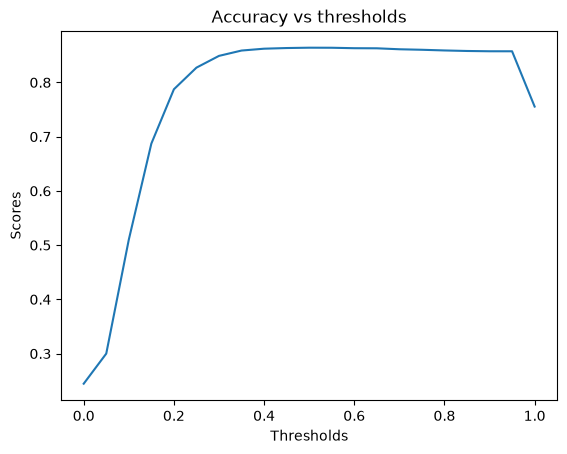

In [ ]:
scores_only = [s[0] for s in scores]
plt.plot(thresholds, scores_only)
plt.xlabel('Thresholds')
plt.ylabel('Scores')
plt.title('Accuracy vs thresholds')

### Confusion matrix for base model

In [ ]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)
predict_positive = (y_val_pred >= best_t)
predict_negative = (y_val_pred < best_t)

tp = (predict_positive & actual_positive).sum()
tn = (predict_negative & actual_negative).sum()
fp = (predict_positive & actual_negative).sum()
fn = (predict_negative & actual_positive).sum()

confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])

confusion_matrix

array([[21470,   248],
       [ 3661,  3368]])

In [ ]:
cm = confusion_matrix(y_val, y_val_pred >= best_t)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Default', 'Default'])
disp.plot(cmap='Blues')


### Precission, Recall and F1 score

In [ ]:
precision = tp / (tp+fp)
recall = tp/ (tp + fn)
precision, recall

(np.float64(0.9314159292035398), np.float64(0.47915777493242284))

In [ ]:
precision_score(y_val, y_val_pred >= best_t)
recall_score(y_val, y_val_pred >= best_t)

print(classification_report(y_val, y_val_pred >= best_t, target_names=['No Default', 'Default']))

              precision    recall  f1-score   support

  No Default       0.85      0.99      0.92     21718
     Default       0.93      0.48      0.63      7029

    accuracy                           0.86     28747
   macro avg       0.89      0.73      0.77     28747
weighted avg       0.87      0.86      0.85     28747



### ROC-AUC 

0.8378491191773871

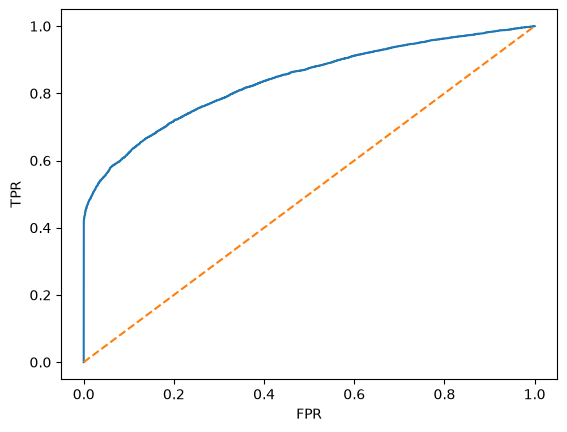

In [ ]:
fpr, tpr, thresholds = roc_curve(y_val, y_val_pred)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.plot(fpr, tpr, label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
roc_auc_score(y_val, y_val_pred)

# Cross Validation and hyperparameter tuning

In [ ]:


# Properly separated param grid so l1_ratio ONLY applies to elasticnet
param_grid = [
    # Grid 1: liblinear (Fast, L1 & L2)
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': np.logspace(-3, 3, 15)
    },
    # Grid 2: SAGA (L1 & L2 only)
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2'],
        'C': np.logspace(-3, 3, 15)
    },
    # Grid 3: SAGA (ElasticNet only - l1_ratio applied exclusively here)
    {
        'solver': ['saga'],
        'penalty': ['elasticnet'],
        'C': np.logspace(-3, 3, 10),
        'l1_ratio': [0.2, 0.5, 0.8]
    },
    # Grid 4: LBFGS (L2 & None)
    {
        'solver': ['lbfgs'],
        'penalty': ['l2', None],
        'C': np.logspace(-3, 3, 15)
    }
]

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=3000, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

In [ ]:
print("Best Hyperparameters:", grid_search.best_params_)
print(f"Best 5-Fold CV ROC-AUC: {grid_search.best_score_:.5f}")

In [ ]:
best_model = grid_search.best_estimator_
y_val_pred = best_model.predict_proba(X_val)[:, 1]
val_roc_auc = roc_auc_score(y_val, y_val_pred)
val_roc_auc

0.8378116034120205

In [ ]:
joblib.dump(best_model, '../models/best_logistic_model.pkl')
print('Model Saved')

Model Saved


In [ ]:
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(encoder, '../models/encoder.pkl')

['../models/encoder.pkl']

In [17]:
best_model = joblib.load('../models/best_logistic_model.pkl')
y_val_pred = best_model.predict_proba(X_val)[:, 1]
val_roc_auc = roc_auc_score(y_val, y_val_pred)

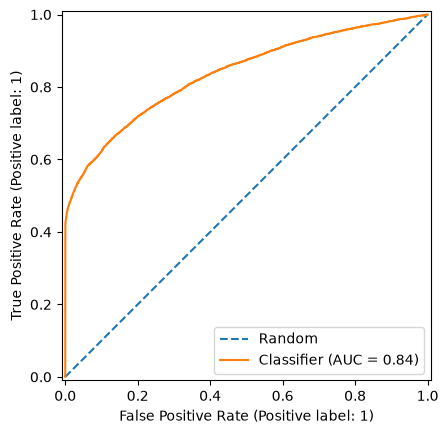

In [18]:
fig, ax = plt.subplots()

ax.plot([0, 1], [0, 1], linestyle='--', label='Random')

RocCurveDisplay.from_predictions(y_val, y_val_pred, ax=ax)

plt.show()

In [19]:
thresholds = np.linspace(0.0, 1.0, 101)
rows = []
pr_intersect = 1000

for t in thresholds:
    y_bin = (y_val_pred >= t).astype(int)

    tp = ((y_bin == 1) & (y_val == 1)).sum()
    fp = ((y_bin == 1) & (y_val == 0)).sum()
    fn = ((y_bin == 0) & (y_val == 1)).sum()
    tn = ((y_bin == 0) & (y_val == 0)).sum()

    precision = precision_score(y_val, y_bin, zero_division=0)
    recall = recall_score(y_val, y_bin, zero_division=0)
    f1 = f1_score(y_val, y_bin, zero_division=0)
    accuracy = accuracy_score(y_val, y_bin)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    balanced_acc = (recall + specificity) / 2
    pred_positive_rate = (tp + fp) / len(y_val)

    rows.append({
        'threshold': t,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'fpr': fpr,
        'npv': npv,
        'f1': f1,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'pred_positive_rate': pred_positive_rate,
        
    })

df_metrics = pd.DataFrame(rows)

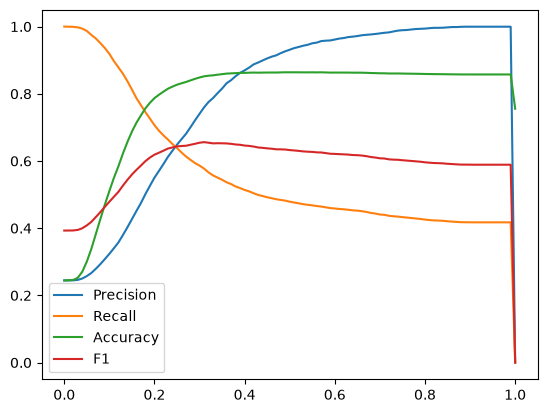

In [20]:
plt.plot(thresholds, df_metrics['precision'], label='Precision')
plt.plot(thresholds, df_metrics['recall'], label='Recall')
plt.plot(thresholds, df_metrics['accuracy'], label='Accuracy')
plt.plot(thresholds, df_metrics['f1'], label='F1')
plt.legend()

# Descision Tree base model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
model.fit(X_train, y_train)
y_val_tree_pred = model.predict_proba(X_val)[:, 1]

In [ ]:
roc_auc_tree = roc_auc_score(y_val, y_val_tree_pred)
roc_auc_tree

0.7711560912495038

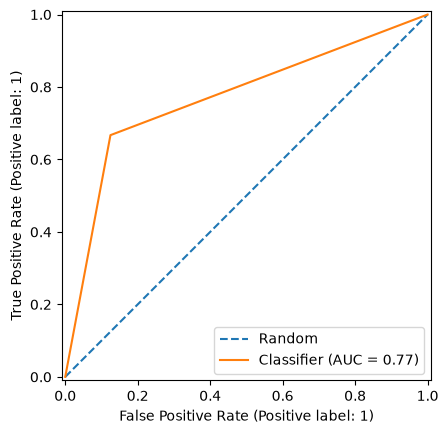

In [ ]:
fig, ax = plt.subplots()

ax.plot([0, 1], [0, 1], linestyle='--', label='Random')

RocCurveDisplay.from_predictions(y_val, y_val_tree_pred, ax=ax)

plt.show()

# Hyperparameter tuning using GridSearchCV

3754

Text(0.5, 0, 'index')

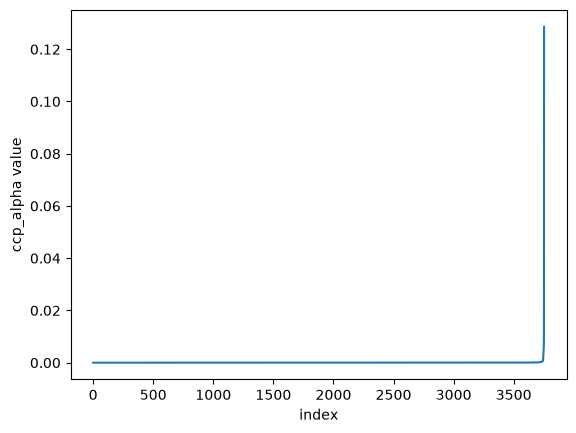

In [ ]:
display(len(ccp_alphas))
plt.plot(ccp_alphas)
plt.ylabel('ccp_alpha value')
plt.xlabel('index')

In [ ]:
param_grid = {
    'ccp_alpha': ccp_alphas[::10]
}
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)

In [ ]:
print(f'Best alpha value: {grid_search.best_params_['ccp_alpha']}')
print(f"Best 5-Fold CV ROC-AUC: {grid_search.best_score_:.5f}")

Best alpha value: 6.639769763389794e-05
Best 5-Fold CV ROC-AUC: 0.87455


In [ ]:
best_tree_model = grid_search.best_estimator_
y_val_tree_pred = best_tree_model.predict_proba(X_val)[:, 1]
val_roc_auc = roc_auc_score(y_val, y_val_tree_pred)
val_roc_auc

0.8729892856624886

In [ ]:
joblib.dump(best_tree_model, '../models/best_tree_model.pkl')

['../models/best_tree_model.pkl']

In [21]:
best_tree_model = joblib.load('../models/best_tree_model.pkl')
y_val_tree_pred = best_tree_model.predict_proba(X_val)[:, 1]
val_roc_auc = roc_auc_score(y_val, y_val_tree_pred)
val_roc_auc

0.8729892856624886

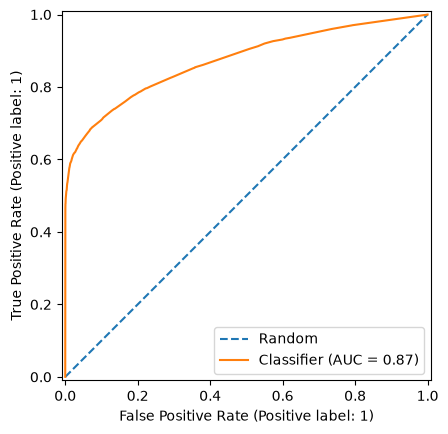

In [22]:
fix, ax = plt.subplots()
ax.plot([0,1], [0,1], linestyle='--', label='Random')
RocCurveDisplay.from_predictions(y_val, y_val_tree_pred, ax=ax)
plt.show()

In [23]:
thresholds = np.linspace(0.0, 1.0, 101)
rows = []

for t in thresholds:
    y_bin = (y_val_tree_pred >= t).astype(int)

    tp = ((y_bin == 1) & (y_val == 1)).sum()
    fp = ((y_bin == 1) & (y_val == 0)).sum()
    fn = ((y_bin == 0) & (y_val == 1)).sum()
    tn = ((y_bin == 0) & (y_val == 0)).sum()

    precision = precision_score(y_val, y_bin, zero_division=0)
    recall = recall_score(y_val, y_bin, zero_division=0)
    f1 = f1_score(y_val, y_bin, zero_division=0)
    accuracy = accuracy_score(y_val, y_bin)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    balanced_acc = (recall + specificity) / 2
    pred_positive_rate = (tp + fp) / len(y_val)

    rows.append({
        'threshold': t,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'fpr': fpr,
        'npv': npv,
        'f1': f1,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'pred_positive_rate': pred_positive_rate,
        
    })

df_metrics_tree = pd.DataFrame(rows)

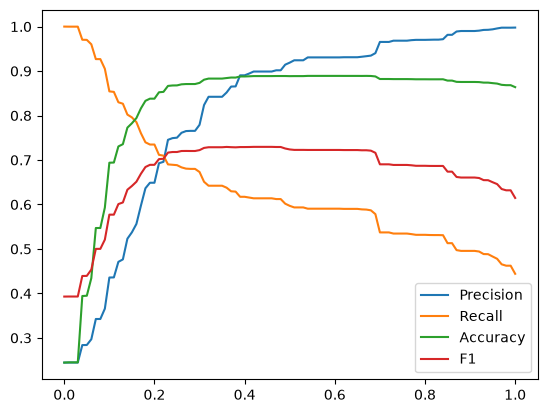

In [24]:
plt.plot(thresholds, df_metrics_tree['precision'], label='Precision')
plt.plot(thresholds, df_metrics_tree['recall'], label='Recall')
plt.plot(thresholds, df_metrics_tree['accuracy'], label='Accuracy')
plt.plot(thresholds, df_metrics_tree['f1'], label='F1')
plt.legend()

# Random Forest base model

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_val_rf_pred = rf.predict_proba(X_val)[:, 1]

In [ ]:
roc_auc_rf = roc_auc_score(y_val, y_val_rf_pred)
roc_auc_rf

0.8830839121222641

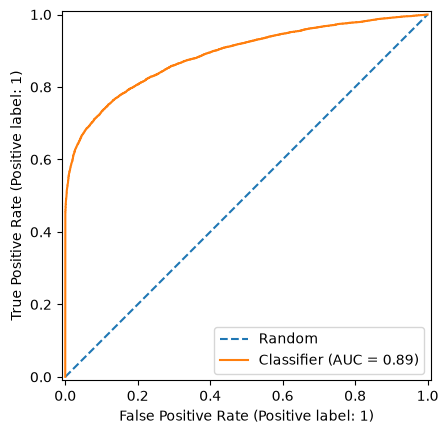

In [ ]:
fig, ax = plt.subplots()
ax.plot([0,1], [0,1], linestyle='--', label='Random')
RocCurveDisplay.from_predictions(y_val, y_val_rf_pred, ax=ax)

# Hyperparameter tuning using RandomizedSearchCV

In [ ]:
param_distributions = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [5, 10, 15, 20, 30, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None]
}

rand_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_distributions,
    random_state=42,
    n_iter=50,
    scoring='roc_auc',
    verbose=2,
    n_jobs=-1
)

rand_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to ba

In [ ]:
print(f'Best hyperparameters: {rand_search.best_params_}')
print(f'Best score: {rand_search.best_score_}')

Best hyperparameters: {'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}
Best score: 0.8885078602208919


In [ ]:
best_rf_model = rand_search.best_estimator_
y_val_rf_pred = best_rf_model.predict_proba(X_val)[:, 1]
val_roc_auc = roc_auc_score(y_val, y_val_rf_pred)
val_roc_auc

0.8894489919945536

In [ ]:
joblib.dump(best_rf_model, '../models/best_rf_model.pkl')

['../models/best_rf_model.pkl']

In [25]:
best_rf_model = joblib.load('../models/best_rf_model.pkl')
y_val_rf_pred = best_rf_model.predict_proba(X_val)[:, 1]
val_roc_auc = roc_auc_score(y_val, y_val_rf_pred)
val_roc_auc


0.8894489919945536

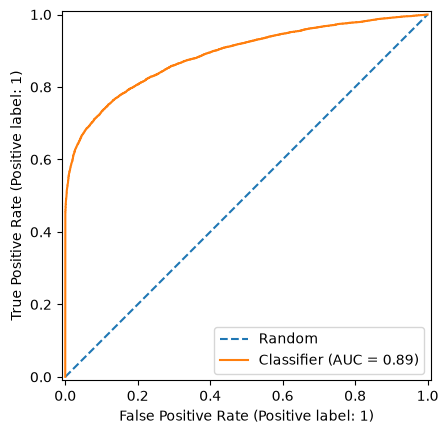

In [26]:
fig, ax = plt.subplots()
ax.plot([0, 1], [0, 1], linestyle='--', label='Random')
RocCurveDisplay.from_predictions(y_val, y_val_rf_pred, ax=ax)

In [27]:
thresholds = np.linspace(0.0, 1.0, 101)
rows = []

for t in thresholds:
    y_bin = (y_val_rf_pred >= t).astype(int)

    tp = ((y_bin == 1) & (y_val == 1)).sum()
    fp = ((y_bin == 1) & (y_val == 0)).sum()
    fn = ((y_bin == 0) & (y_val == 1)).sum()
    tn = ((y_bin == 0) & (y_val == 0)).sum()

    precision = precision_score(y_val, y_bin, zero_division=0)
    recall = recall_score(y_val, y_bin, zero_division=0)
    f1 = f1_score(y_val, y_bin, zero_division=0)
    accuracy = accuracy_score(y_val, y_bin)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    balanced_acc = (recall + specificity) / 2
    pred_positive_rate = (tp + fp) / len(y_val)

    rows.append({
        'threshold': t,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'fpr': fpr,
        'npv': npv,
        'f1': f1,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'pred_positive_rate': pred_positive_rate,
        
    })

df_metrics_rf = pd.DataFrame(rows)

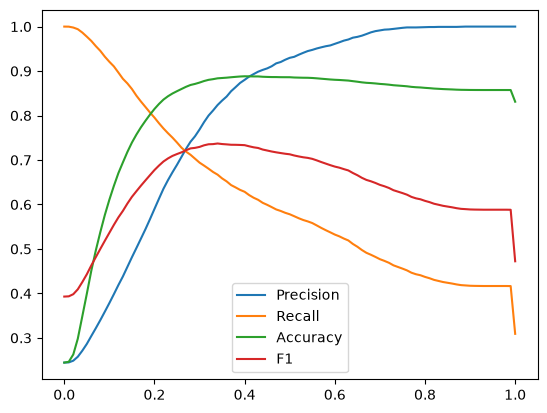

In [28]:
plt.plot(thresholds, df_metrics_rf['precision'], label='Precision')
plt.plot(thresholds, df_metrics_rf['recall'], label='Recall')
plt.plot(thresholds, df_metrics_rf['accuracy'], label='Accuracy')
plt.plot(thresholds, df_metrics_rf['f1'], label='F1')
plt.legend()

# XGBoost

In [ ]:
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)
y_val_xgb_pred = xgb_model.predict_proba(X_val)[:, 1]

In [ ]:
roc_auc_xgb = roc_auc_score(y_val, y_val_xgb_pred)
roc_auc_xgb

0.8879978976497863

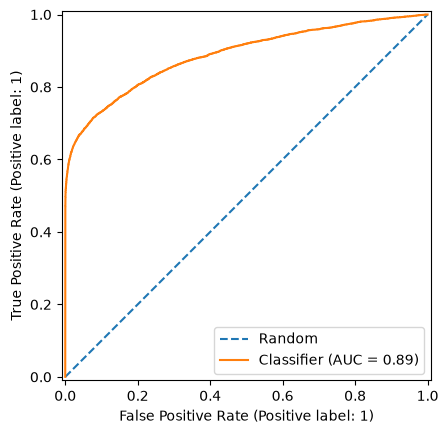

In [ ]:
fig, ax = plt.subplots()
ax.plot([0,1], [0,1], linestyle='--', label='Random')
RocCurveDisplay.from_predictions(y_val, y_val_xgb_pred, ax=ax)

In [ ]:
importance = xgb_model.feature_importances_
df_feature_importance_base = pd.DataFrame({
    'feature': features,
    'importance': importance
}).sort_values(by='importance', ascending=False)
df_feature_importance_base.head(50)

,feature,importance
31,credit_type_equi,0.742658
22,lump_sum_payment_not_lpsm,0.048904
13,loan_type_type3,0.023308
20,neg_ammortization_not_neg,0.020140
17,credit_worthiness_l2,0.018263
40,submission_of_application_to_inst,0.016073
12,loan_type_type2,0.011886
6,dtir1,0.008064
7,loan_limit_ncf,0.007360
11,approv_in_adv_pre,0.007239


# Tuning XGBoost Model

In [ ]:
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5, 1, 2],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1],
    "reg_lambda": [0.5, 1, 2, 5, 10]
}

rand_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        random_state=42,
        eval_metric='auc',
        n_jobs=-1
    ),
    param_distributions=param_distributions,
    random_state=42,
    verbose=2,
    n_jobs=-1,
    scoring='roc_auc',
    n_iter=100
)

rand_search.fit(X_train, y_train)

In [ ]:
print(f'Best hyperparameters: {rand_search.best_params_}')
print(f'Best score: {rand_search.best_score_}')

Best hyperparameters: {'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.7}
Best score: 0.8941621660363355


In [ ]:
best_xgb_model = rand_search.best_estimator_
y_val_xgb_pred = best_xgb_model.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_val_xgb_pred)

0.8940292005371403

In [ ]:
joblib.dump(best_xgb_model, '../models/best_xgb_model.pkl')

['../models/best_xgb_model.pkl']

In [29]:
best_xgb_model = joblib.load('../models/best_xgb_model.pkl')
y_val_xgb_pred = best_xgb_model.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_val_xgb_pred)

0.8940292005371403

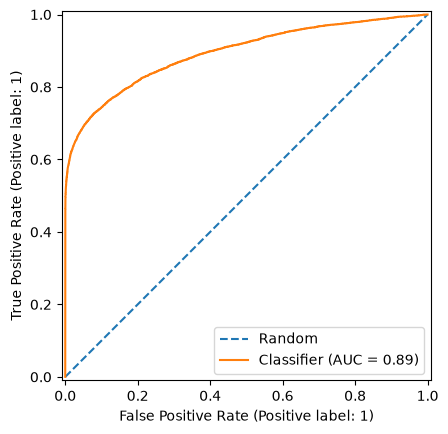

In [30]:
fig, ax = plt.subplots()
ax.plot([0, 1], [0, 1], linestyle='--', label='Random')
RocCurveDisplay.from_predictions(y_val, y_val_xgb_pred, ax=ax)

In [31]:
thresholds = np.linspace(0.0, 1.0, 101)
rows = []

for t in thresholds:
    y_bin = (y_val_xgb_pred >= t).astype(int)

    tp = ((y_bin == 1) & (y_val == 1)).sum()
    fp = ((y_bin == 1) & (y_val == 0)).sum()
    fn = ((y_bin == 0) & (y_val == 1)).sum()
    tn = ((y_bin == 0) & (y_val == 0)).sum()

    precision = precision_score(y_val, y_bin, zero_division=0)
    recall = recall_score(y_val, y_bin, zero_division=0)
    f1 = f1_score(y_val, y_bin, zero_division=0)
    accuracy = accuracy_score(y_val, y_bin)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    balanced_acc = (recall + specificity) / 2
    pred_positive_rate = (tp + fp) / len(y_val)

    rows.append({
        'threshold': t,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'fpr': fpr,
        'npv': npv,
        'f1': f1,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'pred_positive_rate': pred_positive_rate,
        
    })

df_metrics_xgb = pd.DataFrame(rows)

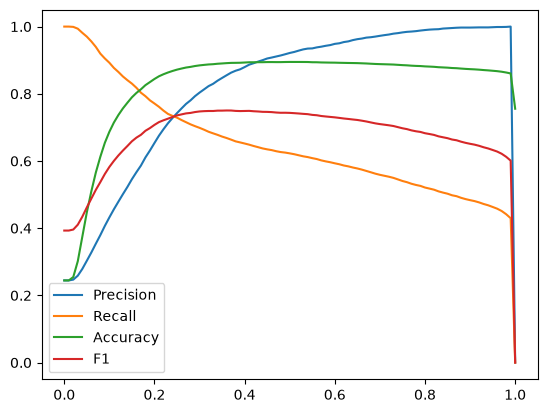

In [32]:
plt.plot(thresholds, df_metrics_xgb['precision'], label='Precision')
plt.plot(thresholds, df_metrics_xgb['recall'], label='Recall')
plt.plot(thresholds, df_metrics_xgb['accuracy'], label='Accuracy')
plt.plot(thresholds, df_metrics_xgb['f1'], label='F1')
plt.legend()

In [33]:
importance = best_xgb_model.feature_importances_
df_feature_importance = pd.DataFrame({
    'feature': features,
    'importance': importance
}).sort_values(by='importance', ascending=False)
df_feature_importance.head(20)

,feature,importance
31,credit_type_equi,0.472104
46,property_value_was_missing_1,0.315071
45,dtir1_was_missing_1,0.036055
22,lump_sum_payment_not_lpsm,0.033455
20,neg_ammortization_not_neg,0.013436
13,loan_type_type3,0.011828
17,credit_worthiness_l2,0.010672
40,submission_of_application_to_inst,0.008668
12,loan_type_type2,0.007550
19,business_or_commercial_nob/c,0.006234


# Compare

In [34]:
print("Logistic regression:")
display(df_metrics.loc[df_metrics['f1'].idxmax()])

print("\nDecision tree:")
display(df_metrics_tree.loc[df_metrics_tree['f1'].idxmax()])

print("\nRandom forest:")
display(df_metrics_rf.loc[df_metrics_rf['f1'].idxmax()])

print("\nXGBoost:")
display(df_metrics_rf.loc[df_metrics_xgb['f1'].idxmax()])

Logistic regression:


threshold                 0.310000
tp                     4058.000000
fp                     1284.000000
fn                     2971.000000
tn                    20434.000000
precision                 0.759641
recall                    0.577323
specificity               0.940879
fpr                       0.059121
npv                       0.873061
f1                        0.656050
accuracy                  0.851985
balanced_accuracy         0.759101
pred_positive_rate        0.185828
Name: 31, dtype: float64


Decision tree:


threshold                 0.420000
tp                     4315.000000
fp                      485.000000
fn                     2714.000000
tn                    21233.000000
precision                 0.898958
recall                    0.613885
specificity               0.977668
fpr                       0.022332
npv                       0.886666
f1                        0.729563
accuracy                  0.888719
balanced_accuracy         0.795777
pred_positive_rate        0.166974
Name: 42, dtype: float64


Random forest:


threshold                 0.340000
tp                     4689.000000
fp                     1004.000000
fn                     2340.000000
tn                    20714.000000
precision                 0.823643
recall                    0.667093
specificity               0.953771
fpr                       0.046229
npv                       0.898499
f1                        0.737148
accuracy                  0.883675
balanced_accuracy         0.810432
pred_positive_rate        0.198038
Name: 34, dtype: float64


XGBoost:


threshold                 0.360000
tp                     4583.000000
fp                      856.000000
fn                     2446.000000
tn                    20862.000000
precision                 0.842618
recall                    0.652013
specificity               0.960586
fpr                       0.039414
npv                       0.895057
f1                        0.735162
accuracy                  0.885136
balanced_accuracy         0.806299
pred_positive_rate        0.189202
Name: 36, dtype: float64

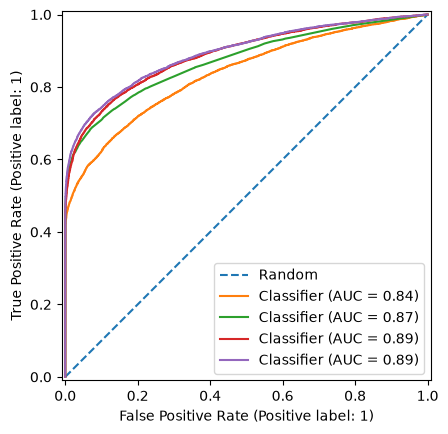

In [35]:
fix, ax = plt.subplots()
ax.plot([0,1], [0,1], linestyle='--', label='Random')
RocCurveDisplay.from_predictions(y_val, y_val_pred, ax=ax)
RocCurveDisplay.from_predictions(y_val, y_val_tree_pred, ax=ax)
RocCurveDisplay.from_predictions(y_val, y_val_rf_pred, ax=ax)
RocCurveDisplay.from_predictions(y_val, y_val_xgb_pred, ax=ax)
plt.show()

In [36]:
from sklearn.metrics import average_precision_score

for name, y_pred in [('logreg', y_val_pred), ('tree', y_val_tree_pred), ('rf', y_val_rf_pred), ('xgb', y_val_xgb_pred)]:
    pr_auc = average_precision_score(y_val, y_pred)
    print(f"{name}: PR-AUC = {pr_auc:.4f}")

logreg: PR-AUC = 0.7566
tree: PR-AUC = 0.8084
rf: PR-AUC = 0.8284
xgb: PR-AUC = 0.8390


In [37]:
target_recall = np.linspace(0.6, 0.80, 31)
for t in target_recall:
    for name, df in [('logreg', df_metrics), ('tree', df_metrics_tree), ('rf', df_metrics_rf), ('xgb', df_metrics_xgb)]:
        candidates = df[df['recall'] >= t]
        if len(candidates):
            best_row = candidates.loc[candidates['precision'].idxmax()]
            print(f"{name}: threshold={best_row['threshold']:.2f}, precision={best_row['precision']:.3f}, recall={best_row['recall']:.3f}")
        else:
            print(f"{name}: never reaches {t} recall")
    print()

logreg: threshold=0.28, precision=0.701, recall=0.603
tree: threshold=0.49, precision=0.914, recall=0.602
rf: threshold=0.44, precision=0.903, recall=0.604
xgb: threshold=0.57, precision=0.940, recall=0.602

logreg: threshold=0.27, precision=0.681, recall=0.613
tree: threshold=0.47, precision=0.902, recall=0.612
rf: threshold=0.43, precision=0.899, recall=0.610
xgb: threshold=0.55, precision=0.935, recall=0.608

logreg: threshold=0.26, precision=0.665, recall=0.626
tree: threshold=0.42, precision=0.899, recall=0.614
rf: threshold=0.42, precision=0.893, recall=0.615
xgb: threshold=0.53, precision=0.932, recall=0.614

logreg: threshold=0.26, precision=0.665, recall=0.626
tree: threshold=0.38, precision=0.866, recall=0.629
rf: threshold=0.41, precision=0.888, recall=0.621
xgb: threshold=0.51, precision=0.924, recall=0.620

logreg: threshold=0.25, precision=0.649, recall=0.638
tree: threshold=0.38, precision=0.866, recall=0.629
rf: threshold=0.40, precision=0.880, recall=0.629
xgb: thresho

# XGBoost without credit_type_equi, property_value_was_missing_1

In [18]:
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)
y_val_xgb_pred = xgb_model.predict_proba(X_val)[:, 1]

In [19]:
roc_auc_xgb = roc_auc_score(y_val, y_val_xgb_pred)
roc_auc_xgb

0.8904272285140883

# Tuned XGBoost, leakage removed

In [20]:
neg, pos = np.bincount(y_train)

ratio = neg / pos

print("Negative:", neg)
print("Positive:", pos)
print("scale_pos_weight:", ratio)

Negative: 65164
Positive: 21235
scale_pos_weight: 3.0687073228161057


In [21]:
param_distributions = {
    "scale_pos_weight": [1, ratio * 0.5, ratio, ratio * 1.5, ratio * 2],
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5, 1, 2],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1],
    "reg_lambda": [0.5, 1, 2, 5, 10]
}

rand_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        random_state=42,
        eval_metric='auc',
        n_jobs=1
    ),
    param_distributions=param_distributions,
    random_state=42,
    verbose=2,
    n_jobs=-1,
    scoring='roc_auc',
    n_iter=100
)

rand_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.7, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance m

In [22]:
print(f'Best hyperparameters: {rand_search.best_params_}')
print(f'Best score: {rand_search.best_score_}')

Best hyperparameters: {'subsample': 1.0, 'scale_pos_weight': 1, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}
Best score: 0.8932941262990454


In [29]:
best_xgb_model2 = rand_search.best_estimator_
y_val_xgb_pred2 = best_xgb_model2.predict_proba(X_val)[:,1]
roc_auc_score(y_val, y_val_xgb_pred2)

NameError: name 'rand_search' is not defined

In [24]:
importance = best_xgb_model2.feature_importances_
df_feature_importance = pd.DataFrame({
    'feature': features,
    'importance': importance
}).sort_values(by='importance', ascending=False)
df_feature_importance.head(20)

,feature,importance
42,dtir1_was_missing_1,0.385443
22,lump_sum_payment_not_lpsm,0.075552
5,ltv,0.053322
2,property_value,0.051009
20,neg_ammortization_not_neg,0.038735
19,business_or_commercial_nob/c,0.036009
17,credit_worthiness_l2,0.035545
37,submission_of_application_to_inst,0.026753
6,dtir1,0.025394
13,loan_type_type3,0.024645


In [32]:
df.groupby(df["dtir1"].isna())["status"].agg(["count", "mean"])

,count,mean
dtir1,,
False,124549,0.163221
True,24121,0.676174


In [33]:
joblib.dump(best_xgb_model2, '../models/best_xgb_model2.pkl')

['../models/best_xgb_model2.pkl']

In [30]:
best_xgb_model2 = joblib.load('../models/best_xgb_model2.pkl')
y_val_xgb_pred2 = best_xgb_model2.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_val_xgb_pred2)

0.8929239921160688

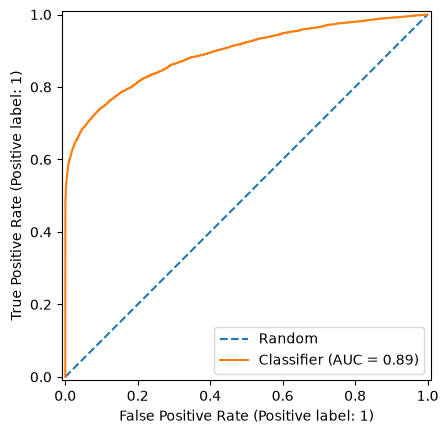

In [40]:
fig, ax = plt.subplots()
ax.plot([0, 1], [0, 1], linestyle='--', label='Random')
RocCurveDisplay.from_predictions(y_val, y_val_xgb_pred2, ax=ax)

In [41]:
thresholds = np.linspace(0.0, 1.0, 101)
rows = []

for t in thresholds:
    y_bin = (y_val_xgb_pred >= t).astype(int)

    tp = ((y_bin == 1) & (y_val == 1)).sum()
    fp = ((y_bin == 1) & (y_val == 0)).sum()
    fn = ((y_bin == 0) & (y_val == 1)).sum()
    tn = ((y_bin == 0) & (y_val == 0)).sum()

    precision = precision_score(y_val, y_bin, zero_division=0)
    recall = recall_score(y_val, y_bin, zero_division=0)
    f1 = f1_score(y_val, y_bin, zero_division=0)
    accuracy = accuracy_score(y_val, y_bin)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    balanced_acc = (recall + specificity) / 2
    pred_positive_rate = (tp + fp) / len(y_val)

    rows.append({
        'threshold': t,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'fpr': fpr,
        'npv': npv,
        'f1': f1,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'pred_positive_rate': pred_positive_rate,
        
    })

df_metrics_xgb2 = pd.DataFrame(rows)

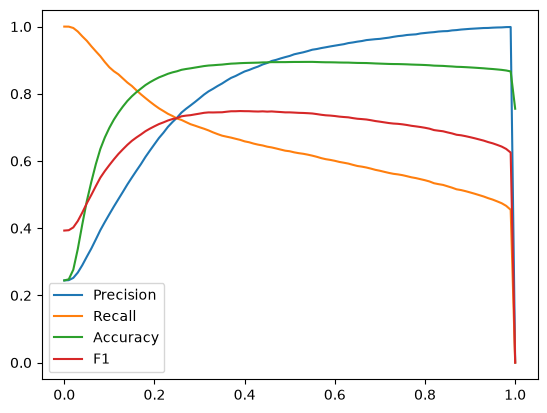

In [42]:
plt.plot(thresholds, df_metrics_xgb2['precision'], label='Precision')
plt.plot(thresholds, df_metrics_xgb2['recall'], label='Recall')
plt.plot(thresholds, df_metrics_xgb2['accuracy'], label='Accuracy')
plt.plot(thresholds, df_metrics_xgb2['f1'], label='F1')
plt.legend()

# XGB imputation

In [35]:
X_train_xgb, y_train_xgb = clean_data_xgb(df_train, encoder=encoder)
X_val_xgb, y_val_xgb = clean_data_xgb(df_val, encoder=encoder)


In [36]:
xgbi_model = xgb.XGBClassifier(
    subsample=1.0,
    scale_pos_weight=1,
    reg_lambda=10,
    reg_alpha=1,
    n_estimators=300,
    min_child_weight=3,
    max_depth=6,
    learning_rate=0.05,
    gamma=0,
    colsample_bytree=0.7,
    random_state=42,
    eval_metric="auc"
)

xgbi_model.fit(X_train_xgb, y_train_xgb)
y_val_xgbi_pred = xgbi_model.predict_proba(X_val_xgb)[:, 1]
roc_auc_score(y_val_xgb, y_val_xgbi_pred)

0.8929239921160688

In [37]:
pred_tuned = best_xgb_model2.predict_proba(X_val)[:, 1]
pred_native = xgbi_model.predict_proba(X_val_xgb)[:, 1]

print("Max difference:",
      np.max(np.abs(pred_tuned - pred_native)))

print("Mean difference:",
      np.mean(np.abs(pred_tuned - pred_native)))

print("Same predictions:",
      np.allclose(pred_tuned, pred_native))

Max difference: 0.0
Mean difference: 0.0
Same predictions: True
